In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import time

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [4]:
from google.colab import files

print("Please upload these 4 files:")
print("X_train.npy, X_test.npy, y_train.npy, y_test.npy")

uploaded = files.upload()
print("\nUploaded files:", list(uploaded.keys()))

Please upload these 4 files:
X_train.npy, X_test.npy, y_train.npy, y_test.npy


Saving X_test.npy to X_test.npy
Saving X_train.npy to X_train.npy
Saving y_test.npy to y_test.npy
Saving y_train.npy to y_train.npy

Uploaded files: ['X_test.npy', 'X_train.npy', 'y_test.npy', 'y_train.npy']


In [5]:
X_train = np.load('X_train.npy')
X_test  = np.load('X_test.npy')
y_train = np.load('y_train.npy')
y_test  = np.load('y_test.npy')

print("X_train shape:", X_train.shape)  # Expected: (n, 6, 6)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (939, 6, 6)
X_test shape : (235, 6, 6)
y_train shape: (939,)
y_test shape : (235,)


In [6]:
def build_conv1d():
    model = models.Sequential()
    model.add(layers.Input(shape=(6, 6)))

    for filters in [32, 32, 64, 64, 64]:
        model.add(layers.Conv1D(filters, kernel_size=3, padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))
        # MaxPool only if sequence length > 1
        if model.output_shape[1] > 1:
            model.add(layers.MaxPooling1D(pool_size=2, padding='same'))

    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))  # binary classification

    return model

model = build_conv1d()
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 6, 32)          │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 3, 32)          │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 3, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 2, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 1, 64)          │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 1, 64)          │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,873 (155.75 KB)

 Trainable params: 39,361 (153.75 KB)

 Non-trainable params: 512 (2.00 KB)

In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
es = EarlyStopping(patience=5, restore_best_weights=True)

start = time.time()

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

elapsed = time.time() - start
print(f'Training time: {elapsed:.1f} seconds')

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9053 - loss: 0.3268 - val_accuracy: 0.7766 - val_loss: 0.5832
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9740 - loss: 0.1078 - val_accuracy: 0.7766 - val_loss: 0.5146
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9822 - loss: 0.0677 - val_accuracy: 0.7766 - val_loss: 0.5344
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9811 - loss: 0.0642 - val_accuracy: 0.7766 - val_loss: 0.5991
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9811 - loss: 0.0540 - val_accuracy: 0.7766 - val_loss: 0.6627
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9858 - loss: 0.0392 - val_accuracy: 0.7766 - val_loss: 0.7893
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9917 - loss: 0.0356 - val_accuracy: 0.7766 - val_loss: 0.8797
Training time: 8.0 seconds


In [9]:
loss, acc = model.evaluate(X_test, y_test)
print(f'\nTest Accuracy : {acc:.4f}')
print(f'Test Loss     : {loss:.4f}')


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8085 - loss: 0.4853 

Test Accuracy : 0.8085
Test Loss     : 0.4853


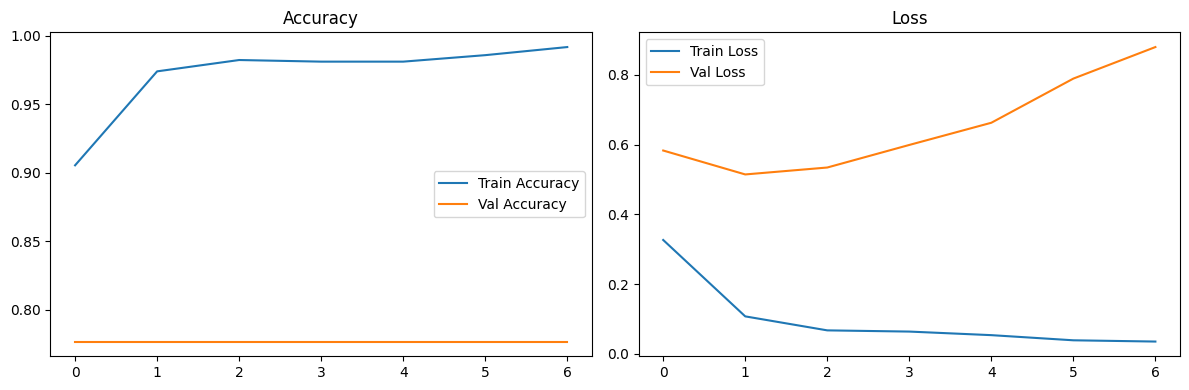

In [10]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

In [11]:
def build_conv1d_v2():
    model = models.Sequential()
    model.add(layers.Input(shape=(6, 6)))

    for filters in [32, 32, 64, 64, 64]:
        model.add(layers.Conv1D(filters, kernel_size=3, padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))
        model.add(layers.Dropout(0.3))  # ADD dropout after each block
        if model.output_shape[1] > 1:
            model.add(layers.MaxPooling1D(pool_size=2, padding='same'))

    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.4))  # stronger dropout before output
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

In [12]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0005),  # slower, more careful learning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [13]:
es = EarlyStopping(patience=10, restore_best_weights=True)  # give more time

history = model.fit(
    X_train, y_train,
    epochs=100,         # more epochs
    batch_size=16,      # smaller batch = better generalization
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9669 - loss: 0.1053 - val_accuracy: 0.7766 - val_loss: 0.5816
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9763 - loss: 0.0806 - val_accuracy: 0.7766 - val_loss: 0.7219
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9775 - loss: 0.0644 - val_accuracy: 0.7766 - val_loss: 0.8507
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9740 - loss: 0.0723 - val_accuracy: 0.7766 - val_loss: 0.7550
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9905 - loss: 0.0426 - val_accuracy: 0.8085 - val_loss: 0.4446
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9799 - loss: 0.0618 - val_accuracy: 0.8404 - val_loss: 0.4367
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9822 - loss: 0.0491 - val_accuracy: 0.9043 - val_loss: 0.2268
Epoch 8/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9775 - loss: 0.0596 - val_accuracy: 0.9255 - 

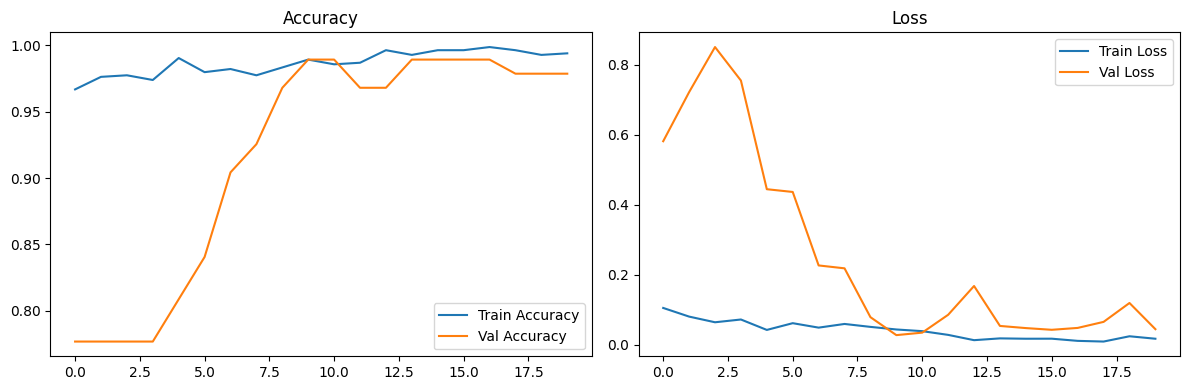

In [14]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 161ms/step


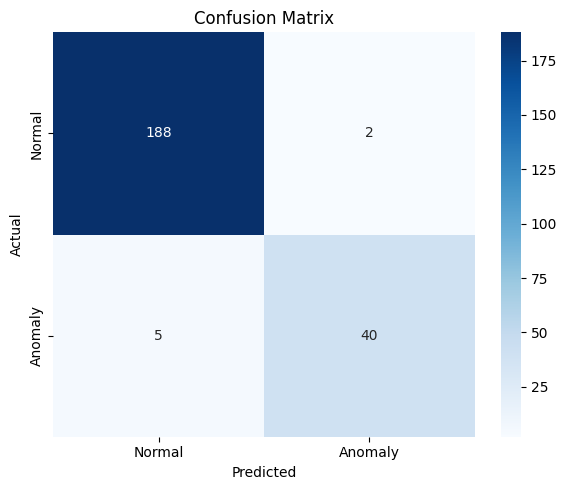

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = (model.predict(X_test) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Anomaly'],
            yticklabels=['Normal','Anomaly'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Normal', 'Anomaly']))

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98       190
     Anomaly       0.95      0.89      0.92        45

    accuracy                           0.97       235
   macro avg       0.96      0.94      0.95       235
weighted avg       0.97      0.97      0.97       235



8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


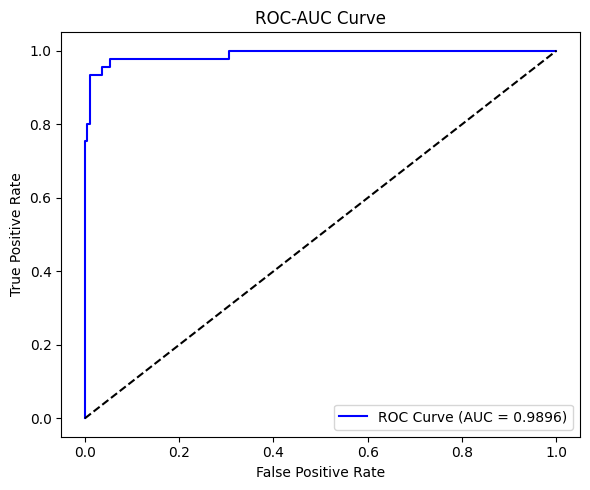

In [17]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict(X_test)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue',
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend()
plt.tight_layout()
plt.show()